# Privacy-Preserving Federated Network Intrusion Detection System

## Notebook 04 - Feature Engineering

### Objectives

- Analyze the processed features
- Remove constant features
- Identify highly correlated features
- Analyze feature importance
- Create the final feature set for model training

In [2]:
# =====================================================
# Import necessary libraries
# =====================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [15]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "CICIDS2017_processed.csv"
)

RESULTS_PATH = PROJECT_ROOT / "results"
FIGURES_PATH = RESULTS_PATH / "figures"
METRICS_PATH = RESULTS_PATH / "metrics"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

print(PROCESSED_PATH)

c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_processed.csv


In [16]:
# =====================================================
# LOAD PROCESSED DATASET
# =====================================================

df = pd.read_csv(PROCESSED_PATH)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2520798, 79)


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,2.428596,-0.470914,-0.010425,-0.010950,-0.056662,-0.007566,-0.297774,-0.217169,-0.294064,-0.260452,...,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
1,2.438537,-0.470911,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,...,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
2,2.438590,-0.470913,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,...,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
3,1.974744,-0.470913,-0.011684,-0.010003,-0.057228,-0.007563,-0.297774,-0.217169,-0.294064,-0.260452,...,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0
4,2.428491,-0.470914,-0.010425,-0.010950,-0.056662,-0.007566,-0.297774,-0.217169,-0.294064,-0.260452,...,0.002698,-0.13337,-0.110882,-0.158458,-0.107114,-0.375777,-0.11608,-0.381137,-0.361764,0


In [17]:
# =====================================================
# SEPARATE FEATURES AND TARGET
# =====================================================

X = df.drop(columns=["Label"])
y = df["Label"]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (2520798, 78)
Target: (2520798,)


In [19]:
# =====================================================
#  IDENTIFY CONSTANT FEATURES
# =====================================================

constant_features = [
    column
    for column in X.columns
    if X[column].nunique() <= 1
]

print(f"Constant features found: {len(constant_features)}")

if constant_features:
    print(constant_features)

X = X.drop(columns=constant_features)

print(f"Features after removal: {X.shape[1]}")

Constant features found: 0
Features after removal: 70


In [20]:
# =====================================================
# IDENTIFY HIGHLY CORRELATED FEATURES
# =====================================================

correlation_matrix = X.corr().abs()

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_correlation_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

print(
    f"Highly correlated features: "
    f"{len(high_correlation_features)}"
)

high_correlation_features[:20]

Highly correlated features: 23


['Total_Backward_Packets',
 'Total_Length_of_Bwd_Packets',
 'Fwd_Packet_Length_Std',
 'Bwd_Packet_Length_Mean',
 'Bwd_Packet_Length_Std',
 'Fwd_IAT_Total',
 'Fwd_IAT_Max',
 'Fwd_Packets_s',
 'Packet_Length_Std',
 'SYN_Flag_Count',
 'CWE_Flag_Count',
 'ECE_Flag_Count',
 'Average_Packet_Size',
 'Avg_Fwd_Segment_Size',
 'Avg_Bwd_Segment_Size',
 'Fwd_Header_Length.1',
 'Subflow_Fwd_Packets',
 'Subflow_Fwd_Bytes',
 'Subflow_Bwd_Packets',
 'Subflow_Bwd_Bytes']

In [21]:
# =====================================================
# REMOVE REDUNDANT FEATURES
# =====================================================

X_reduced = X.drop(
    columns=high_correlation_features
)

print(f"Original features : {X.shape[1]}")
print(f"Final features    : {X_reduced.shape[1]}")

Original features : 70
Final features    : 47


In [22]:
# =====================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =====================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_reduced, y)

feature_importance = pd.DataFrame({
    "Feature": X_reduced.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Destination_Port,0.077344
39,Init_Win_bytes_backward,0.066137
29,Max_Packet_Length,0.043818
26,Bwd_Header_Length,0.043666
4,Fwd_Packet_Length_Max,0.043601
7,Bwd_Packet_Length_Max,0.043385
30,Packet_Length_Mean,0.042450
11,Flow_IAT_Mean,0.039453
16,Fwd_IAT_Std,0.034222
41,min_seg_size_forward,0.032611


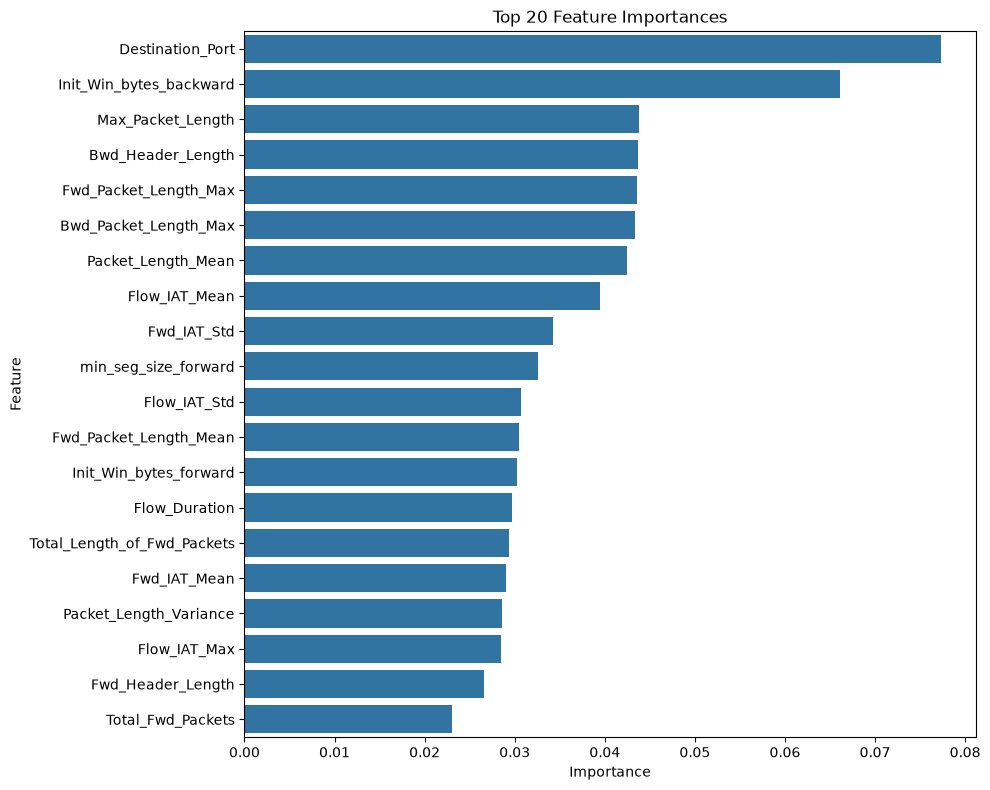

In [23]:
# =====================================================
# FEATURE IMPORTANCE VISUALIZATION
# =====================================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# =====================================================
# SELECT FINAL FEATURES
# =====================================================

importance_threshold = 0.001

selected_features = feature_importance[
    feature_importance["Importance"] >= importance_threshold
]["Feature"].tolist()

print(f"Selected features: {len(selected_features)}")

Selected features: 43


In [25]:
# =====================================================
# CREATE FINAL FEATURE-ENGINEERED DATASET
# =====================================================

X_final = X_reduced[selected_features].copy()

final_df = X_final.copy()
final_df["Label"] = y

print(f"Final dataset shape: {final_df.shape}")

Final dataset shape: (2520798, 44)


In [26]:
# =====================================================
# SAVE FEATURE ENGINEERING OUTPUTS
# =====================================================

feature_importance.to_csv(
    METRICS_PATH / "feature_importance.csv",
    index=False
)

pd.DataFrame({
    "Selected_Feature": selected_features
}).to_csv(
    METRICS_PATH / "selected_features.csv",
    index=False
)

final_df.to_csv(
    PROCESSED_PATH.parent / "CICIDS2017_feature_engineered.csv",
    index=False
)

print("Feature engineering outputs saved successfully.")

Feature engineering outputs saved successfully.
